# Individual Analysis

This notebooks aims at exploring the data on an Indiviudal LEvel: checking a single subject for their validity! 


### Load and Preprocess Participant Raw Data

This code Gets the data a specific filename and Loads it as a RawDF
as well as events getting specific strctutes for Saccade, blinks and Fizations, as well as my Own Events 

In [ ]:
import numpy as np
from analysisFunctions import *
import os 
import pandas as pd

filename = "ADga2904"
verbose  = 1;

pd.set_option("display.max_rows",10)
workingDir = os.getcwd();
if os.path.isdir(os.path.join(workingDir,filename)) == 0:
    os.makedirs(os.path.join(workingDir,filename))
path = os.path.split(workingDir)
log_file = open(os.path.join(workingDir,filename,filename+"_preprocLog.txt"),'w+')


log_file.write(" "*15+"="*58 + "\n")
log_file.write(" "*15+"="*5+ " "*15+" PREPROC LOG FILE"+ " "*15+"="*5+ " \n")
log_file.write(" "*15+"="*58 + "\n\n")
log_file.write("\n===# Load and Prepare Data #=== \n\n")

### (1) -----  Load Particpant data getting Events Raw EyeData and My owb events as well as Screen Coordinates  ---- 
log_file.write("    Loading Participant Data... ")

[own,rawEye, events, gazeCoords] = loadParticipant(workingDir, name=filename) # Gets my RawEye Data as well as events and gaze Coordination
RawDF = pd.DataFrame(rawEye,columns=["TimePoint",'LeftX','LeftY','LeftPupil','RightX','RightY','RightPupil']);
log_file.write("done \n")


# (2) ----- Get Eyelink Events ------ 
log_file.write("    Getting Events...           ")
fixationDF,saccadesDF,blinkDF = getEvent(events)
log_file.write("done \n")

# Change Timing so it will be relative from the start of the experiment
log_file.write("    Changing Timing....         ")
RawDF,fixationDF,saccadesDF,blinkDF,own = changeTiming(RawDF,fixationDF,saccadesDF,blinkDF,own)
log_file.write("done \n")


# (3) ----- Get your custom Events ------ 
# Parse your own events getting a Wide format getting only PARTS with their Timing  (Maybe Write Checks?)
log_file.write("    Getting Own Events...       ")
event_dfs = parse_events(own)
event_dfs = rename_parts(event_dfs) # Be sure that the numeration for each entity part is Correct! 
log_file.write("done \n")
if len(event_dfs) != 40:
    log_file.write("    WARNING! the events are not whole!       ")
log_file.write("\n            Events DataFrame:       \n")

log_file.write(event_dfs.describe().to_string())


# (4) ----- Split rawDF and eventsDFs according to yout OWN Events 
# Contains All our Data but now Comnvienientl Split for a stories 
log_file.write("\n\n    Splitting by events...      ")
split_data = split_dataframes_by_events(RawDF, fixationDF, saccadesDF, blinkDF, event_dfs)
log_file.write("done \n")


6

#### Plot General Data only relevant to trials: 

Plotting Gaze Checksw - including Pupil Distributyion for LEft, right Eye and so on...


(1) Check mean Gaze Center

                              X          Y
Middle Screen Coordinates:  959.5       539.5
Mean Eye Coordinates:      1066.5       597.2

(2) Check Missing Pupil Data as a proxy for missing!

Number of NoGaze Data: 
(Left: 93456, Right: 63191), Both: 61987

 (3) Pupil Difference Test 

    Percentage Difference: 0.032616299123262464


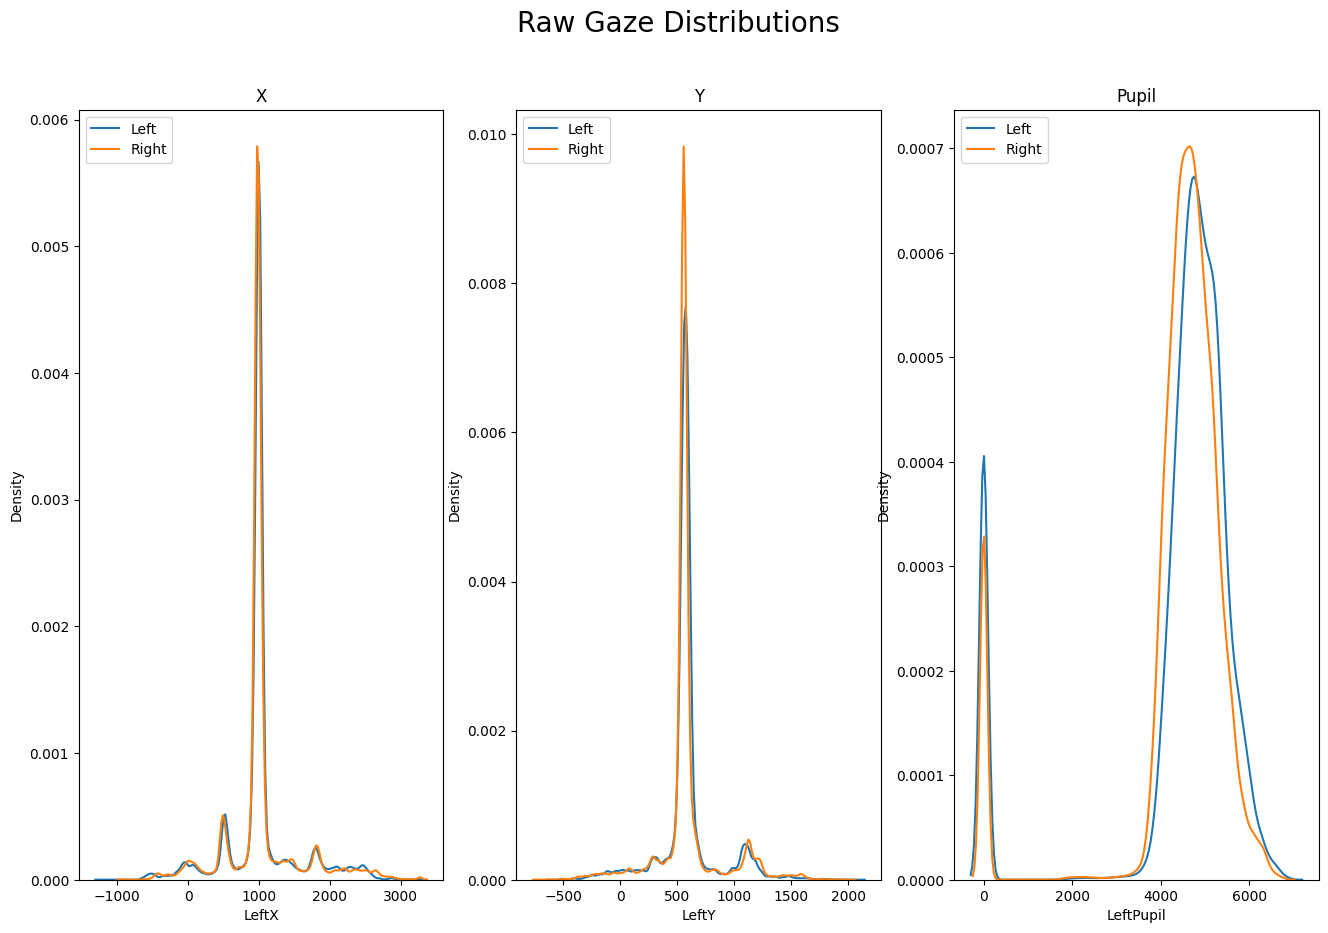

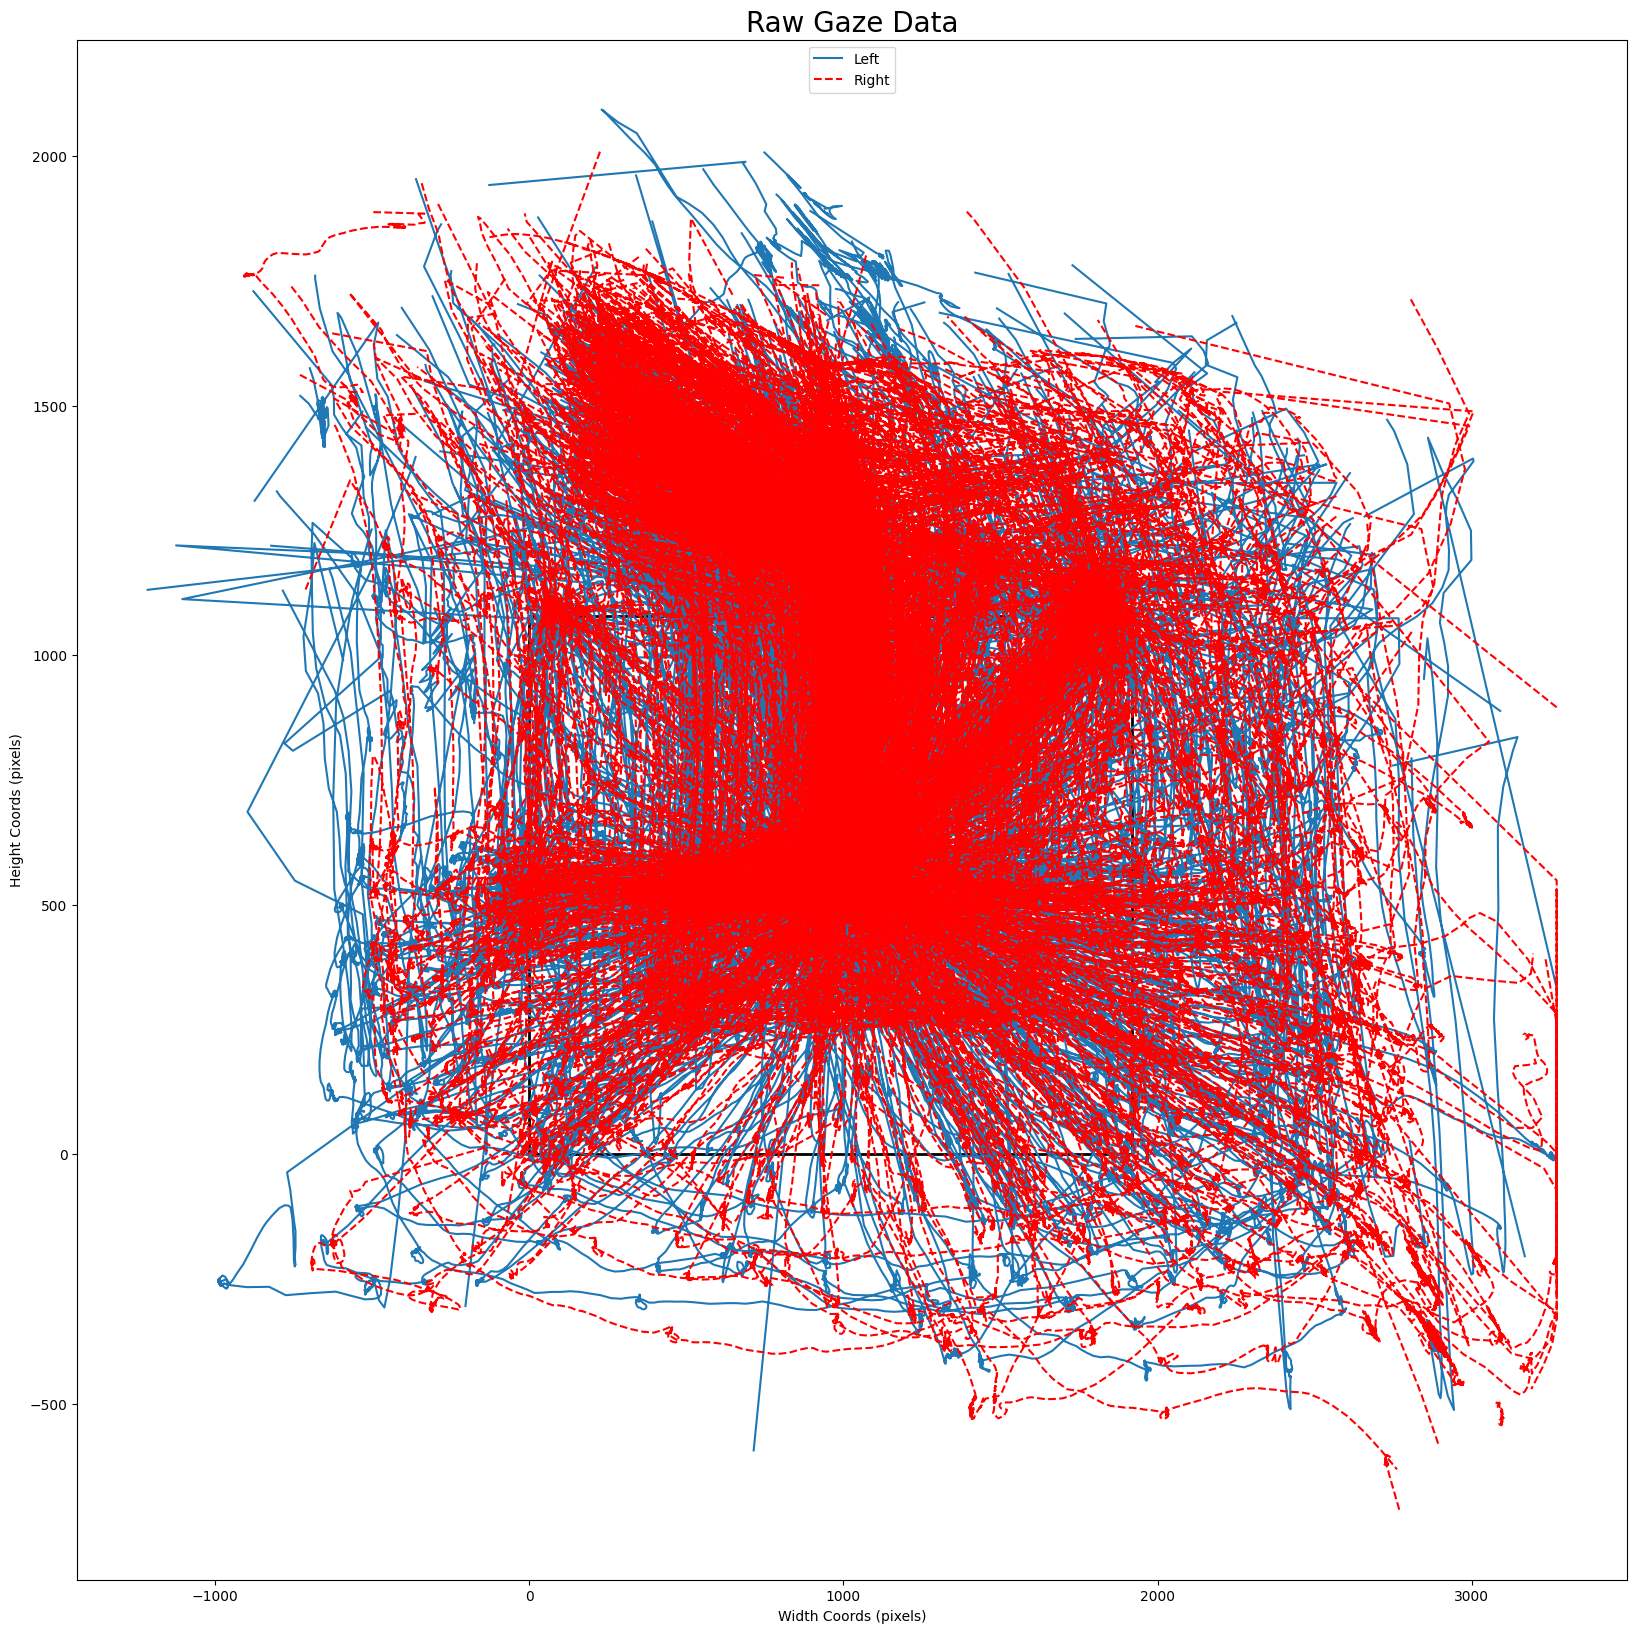

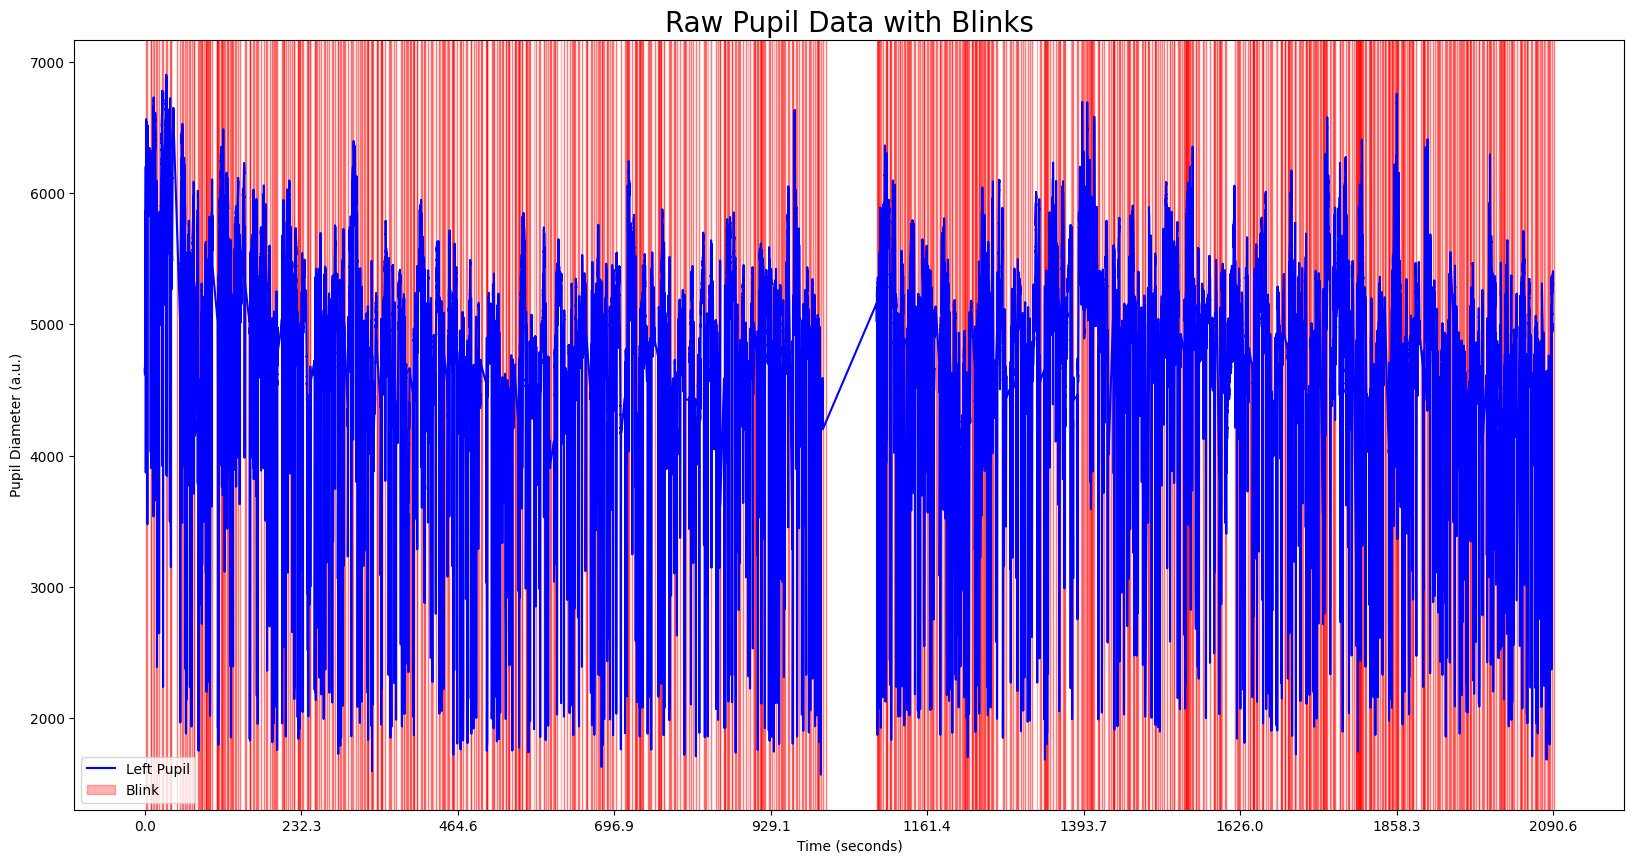

In [3]:
log_file.write("\n===# Stats and Checks for Unfiltered Data #=== \n\n ")


[firstEntityRaw, secondEntityRaw] = splitEntities(RawDF, event_dfs)
[firstEntityBlinks, secondEntityBlinks] = splitEntities(blinkDF, event_dfs)
[firstEntitySaccades, secondEntitySaccades] = splitEntities(saccadesDF, event_dfs)
[firstEntityFixation, secondEntityFixation] = splitEntities(fixationDF, event_dfs)

allEntities = pd.concat([firstEntityRaw, secondEntityRaw], ignore_index=True)
allEntities.sort_values(by='TimePoint', inplace=True)

log_file.write("\n===# Stats and Checks for Experiment Relevant only Data #=== \n\n ")

[RawDFPupilTrue,log_file] = GeneralChecks(allEntities, blinkDF, saccadesDF, fixationDF, gazeCoords,log_file=log_file)




fig1 = eyeRawKDE(RawDF)
plt.savefig(os.path.join(workingDir,filename,filename+"_Distribution_filt.png"))
plotRawGaze(RawDF,gazeCoords)
plt.savefig(os.path.join(workingDir,filename,filename+"_RawGaze_filt.png"))
plotPupilTimecourse(RawDFPupilTrue, "Raw Pupil Data with Blinks", blinkDF, saccadesDF, fixationDF, chooseViz='001')
plt.savefig(os.path.join(workingDir,filename,filename+"_RawPupil_filt.png"))


### Data Quality Metrics for a particpant

Including (For Each Entity and Halve of experiment)
+ Blink Rate 
+ Rate of Outside of Screen Events
+ Mean Gaze Deviation (mean + sd)
+ Mean and SD Saccade
+ Mean and SD Pupil Diameter
+ Mean and SD Left-Right Deviation 

In [4]:

gazeDiff, pupilDiff, saccDiff, blinkDiff, eyeposDiff, nogazeRate,_,_ = qualiryMetrics([firstEntityRaw, secondEntityRaw], [firstEntitySaccades, secondEntitySaccades], [firstEntityBlinks, secondEntityBlinks], gazeCoords,log_file=log_file)



    (1) Quality Metrics:

    Metric                           Left      Right
    Coordinate Difference:      109.15000  112.45068
    Rate of No Gaze Data:         0.10293    0.06832
    Saccade Count:                   1534       1597
    Blink Count:                      342        333

    Pupil Relative Diff (L-R):    0.03187 (±0.06068)
    Eye Position Mismatch (X):   38.35156 (±48.29333)


    (2) Quality Metrics:

    Metric                           Left      Right
    Coordinate Difference:      134.74748  136.21523
    Rate of No Gaze Data:         0.10394    0.07153
    Saccade Count:                   1608       1667
    Blink Count:                      367        362

    Pupil Relative Diff (L-R):    0.03335 (±0.06265)
    Eye Position Mismatch (X):   37.94759 (±52.66733)




#### New Individual Procedure:

Main Processing Loop: Iterates throgh trials (Established previously ), and Invokes on each a **preprocessingPipeline** function, to Clean Pupilometric Data 

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from analysisFunctions import (
    downsamplePupil,
    interpolate_blinks,
    plotPupilTimecourse,
    removeOutliers,
    replace_zero_clusters_with_nans,
    smooth_pupil_data,
    count_gaze_outside,
    plotEyeWithBlink,
    preprocessingPipeline
)

# Other Checks:
storyIndCheck = {}

verbose = 1
resRate = 100
dgvCent = 5
blinkInt = 0;
maxblength = 500
blkboundry = 75
blinkbegbound = 1000
smoothwin = 10
maxcluslen = 2000
mingaplen = 50;
trialOffset = 10000
baseOffset = 0

paramsDict ={verbose:verbose,
            resRate:resRate,
            dgvCent:dgvCent,
            blinkInt:blinkInt,
            maxblength:maxblength,
            blkboundry:blkboundry,
            blinkbegbound:blinkbegbound,
            smoothwin:smoothwin,
            maxcluslen:maxcluslen,
            mingaplen:mingaplen
}
# Define output directory
output_dir =os.path.join(workingDir,filename)

# Define PDF paths
pdf_path_downsampled = os.path.join(output_dir, "Downsampled_Pupil_Data.pdf")
pdf_path_screen_only = os.path.join(output_dir, "Screen_Only.pdf")
pdf_path_blink_rejection = os.path.join(output_dir, "After_Pupil_Artefacts_Rejection.pdf")
pdf_path_outlier_rejection = os.path.join(output_dir, "After_Outlier_Rejection.pdf")
pdf_path_centered = os.path.join(output_dir, "CenteredPupil.pdf")
pdf_path_nan_rejection = os.path.join(output_dir,"NaN_rejected_Pupil.pdf")
# Open PdfPages objects for each PDF

pdf_downsampled = PdfPages(pdf_path_downsampled)
pdf_center_only = PdfPages(pdf_path_screen_only)
pdf_blink_rejection = PdfPages(pdf_path_blink_rejection)
pdf_outlier_rejection = PdfPages(pdf_path_outlier_rejection)

pdf_nan_rejection = PdfPages(pdf_path_nan_rejection)
pdf_smoothed = PdfPages(pdf_path_centered)
log_file.write("\n===# Preprocessing the Data #=== \n\n ")
log_file.write(f"    Preproc Parameters: General: \n")
log_file.write(f"        Verbose:              {verbose}\n")
log_file.write(f"        Resampling Rate:      {resRate}\n")
log_file.write(f"        DGV from Center:      {dgvCent}\n\n")
log_file.write(f"    Preproc Parameters: Blinks: \n")
log_file.write(f"        Blink Interpolation:  {blinkInt}\n")
log_file.write(f"        Maximum Blink Length: {maxblength}\n")
log_file.write(f"        Blink Interp Bound:   {blkboundry}\n")
log_file.write(f"        Blink Begining Bound: {blinkbegbound}\n\n")
log_file.write(f"    Preproc Parameters: Smooth: \n")
log_file.write(f"        Window size:          {smoothwin}\n")
log_file.write(f"        Minimal Cluster len:  {maxcluslen}\n")
log_file.write(f"        Maximal Gap Length:   {mingaplen}\n\n")
# Iterate through events of split_data
data = {};
finalDataStruct = {}
resultsL = np.zeros((len(split_data['STORY_1']['RawDF']), 4))
resultsR = np.zeros((len(split_data['STORY_1']['RawDF']), 4))
iterCounter = 0
for story, data_dict in split_data.items():
    finalDataStruct[story] = {}
    data[story] = {}
    
    for part, RawDF in data_dict['RawDF'].items():
        print(f"\nAnalysing: {story} // {part} ")
        log_file.write(f"    ### Analysing: {story} // {part} ###\n")
        data[story][part] = {}

        blinkDF = data_dict['blinkDF'][part]
        saccadesDF = data_dict['saccadesDF'][part]


        finalData = preprocessingPipeline(blinkDF,RawDF,saccadesDF,gazeCoords,story,part,log_file=log_file,pdfs=[pdf_downsampled,pdf_center_only,pdf_blink_rejection ,pdf_outlier_rejection ,pdf_nan_rejection,pdf_smoothed],
                                        verbose=verbose,interp_type=blinkInt,interpBoundary=blkboundry,maxBlinkDur=maxblength,resampleRate=resRate,
                                        dgvCenter=dgvCent,smoothwin=smoothwin, min_cluster_duration=maxcluslen,max_gap_duration=mingaplen)
        
        log_file.write("\n        Final Data Stats: \n")
        log_file.write(finalData.describe().to_string().replace('\n', '\n\t\t').join(['\t\t', ''])) # Adds two Tabulations!
        log_file.write("\n\n")
        log_file.write("        Sanity Checks on Final Data: \n")
        log_file.write(f"            Number of Non-missing Data events: {len(finalData['LeftPupil'].dropna())} ({len(finalData['LeftPupil'].dropna())/len(finalData)} %)\n")
        gazeD, _, _, _, _, _,pupil_mean,mean_eye_diff  = qualiryMetrics([finalData], [saccadesDF], [blinkDF], gazeCoords, log_file)
        

        iterCounter+=1;

        finalDataStruct[story][part] = finalData;
        data[story][part]['Gaze']     =finalData;
        data[story][part]['Blinks']   =blinkDF;
        data[story][part]['Saccades'] =saccadesDF;


    # Close PdfPages objects
    pdf_downsampled.close()
    pdf_center_only.close()
    pdf_blink_rejection.close()
    pdf_outlier_rejection.close()
    pdf_smoothed.close()
    pdf_nan_rejection.close()
    print("Processing complete. PDFs saved.")
    log_file.write("\n===# Preprocessing Completed Successfully #===\n")
    log_file.write(f"  Total trials processed: {iterCounter}\n")
    log_file.write(f"  FinalDataStruct contains stories: {list(finalDataStruct.keys())}\n")
    log_file.write("===# End of Preprocessing Section #===\n\n")




Analysing: STORY_1 // KAROLINA_1 
    Downsampling to rate 100.0 Hz
    Removing Points from Outside of the Gaze by 5 dg. 
    Removing Points from Outside of the Gaze by 5 dg. 
    Interpolating or NaN Outliers in LeftPupil eye N:4257.0
    Interpolating or NaN Outliers in RightPupil eye N:4257.0
    Found 6 clusters for LeftPupil.
    Cluster smoothed for LeftPupil: Duration=2470.0.
    Cluster smoothed for LeftPupil: Duration=7400.0.
    Cluster smoothed for LeftPupil: Duration=4410.0.
    Cluster smoothed for LeftPupil: Duration=17660.0.
    Cluster smoothed for LeftPupil: Duration=6200.0.
    Cluster smoothed for LeftPupil: Duration=2930.0.
    Found 6 clusters for RightPupil.
    Cluster smoothed for RightPupil: Duration=2470.0.
    Cluster smoothed for RightPupil: Duration=7410.0.
    Cluster smoothed for RightPupil: Duration=4410.0.
    Cluster smoothed for RightPupil: Duration=17650.0.
    Cluster smoothed for RightPupil: Duration=6200.0.
    Cluster smoothed for RightPupil: 

C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:126: RuntimeWarning: Mean of empty slice
  resultsL[iterCounter,:] =  [meanPupilL.mean(), meanPupilL.std(),np.nanmean(np.diff(meanPupilL)), event_dfs[event_dfs["Part"] == part]['key'].values[0]]
C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:127: RuntimeWarning: Mean of empty slice
  resultsR[iterCounter,:] =  [meanPupilR.mean(), meanPupilR.std(),np.nanmean(np.diff(meanPupilR)), event_dfs[event_dfs["Part"] == part]['key'].values[0]]


    Removing Points from Outside of the Gaze by 5 dg. 
    Removing Points from Outside of the Gaze by 5 dg. 
    Interpolating or NaN Outliers in LeftPupil eye N:4503.0
    Interpolating or NaN Outliers in RightPupil eye N:4503.0
    Found 15 clusters for LeftPupil.
    Cluster replaced with NaN for LeftPupil: Duration=260.0, Gap=None.
    Cluster replaced with NaN for LeftPupil: Duration=360.0, Gap=960.0.
    Cluster smoothed for LeftPupil: Duration=3570.0.
    Cluster replaced with NaN for LeftPupil: Duration=120.0, Gap=790.0.
    Cluster smoothed for LeftPupil: Duration=6500.0.
    Cluster replaced with NaN for LeftPupil: Duration=1280.0, Gap=620.0.
    Cluster smoothed for LeftPupil: Duration=4740.0.
    Cluster smoothed for LeftPupil: Duration=2700.0.
    Cluster replaced with NaN for LeftPupil: Duration=1700.0, Gap=1570.0.
    Cluster replaced with NaN for LeftPupil: Duration=1850.0, Gap=560.0.
    Cluster replaced with NaN for LeftPupil: Duration=1450.0, Gap=1440.0.
    Cluster

C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:126: RuntimeWarning: Mean of empty slice
  resultsL[iterCounter,:] =  [meanPupilL.mean(), meanPupilL.std(),np.nanmean(np.diff(meanPupilL)), event_dfs[event_dfs["Part"] == part]['key'].values[0]]
C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:127: RuntimeWarning: Mean of empty slice
  resultsR[iterCounter,:] =  [meanPupilR.mean(), meanPupilR.std(),np.nanmean(np.diff(meanPupilR)), event_dfs[event_dfs["Part"] == part]['key'].values[0]]


    Removing Points from Outside of the Gaze by 5 dg. 
    Removing Points from Outside of the Gaze by 5 dg. 
    Interpolating or NaN Outliers in LeftPupil eye N:4386.0
    Interpolating or NaN Outliers in RightPupil eye N:4386.0
    Found 22 clusters for LeftPupil.
    Cluster replaced with NaN for LeftPupil: Duration=0.0, Gap=None.
    Cluster replaced with NaN for LeftPupil: Duration=100.0, Gap=310.0.
    Cluster replaced with NaN for LeftPupil: Duration=230.0, Gap=500.0.
    Cluster replaced with NaN for LeftPupil: Duration=10.0, Gap=1190.0.
    Cluster replaced with NaN for LeftPupil: Duration=270.0, Gap=130.0.
    Cluster replaced with NaN for LeftPupil: Duration=880.0, Gap=280.0.
    Cluster replaced with NaN for LeftPupil: Duration=410.0, Gap=820.0.
    Cluster replaced with NaN for LeftPupil: Duration=1510.0, Gap=1900.0.
    Cluster replaced with NaN for LeftPupil: Duration=870.0, Gap=1160.0.
    Cluster replaced with NaN for LeftPupil: Duration=860.0, Gap=1450.0.
    Cluster

...

C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:126: RuntimeWarning: Mean of empty slice
  resultsL[iterCounter,:] =  [meanPupilL.mean(), meanPupilL.std(),np.nanmean(np.diff(meanPupilL)), event_dfs[event_dfs["Part"] == part]['key'].values[0]]
C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:127: RuntimeWarning: Mean of empty slice
  resultsR[iterCounter,:] =  [meanPupilR.mean(), meanPupilR.std(),np.nanmean(np.diff(meanPupilR)), event_dfs[event_dfs["Part"] == part]['key'].values[0]]


    Removing Points from Outside of the Gaze by 5 dg. 
    Interpolating or NaN Outliers in LeftPupil eye N:4100.0
    Interpolating or NaN Outliers in RightPupil eye N:4100.0
    Found 18 clusters for LeftPupil.
    Cluster replaced with NaN for LeftPupil: Duration=240.0, Gap=None.
    Cluster replaced with NaN for LeftPupil: Duration=140.0, Gap=1710.0.
    Cluster replaced with NaN for LeftPupil: Duration=320.0, Gap=2150.0.
    Cluster replaced with NaN for LeftPupil: Duration=1380.0, Gap=2200.0.
    Cluster replaced with NaN for LeftPupil: Duration=430.0, Gap=600.0.
    Cluster replaced with NaN for LeftPupil: Duration=210.0, Gap=960.0.
    Cluster replaced with NaN for LeftPupil: Duration=1230.0, Gap=410.0.
    Cluster replaced with NaN for LeftPupil: Duration=1580.0, Gap=2370.0.
    Cluster replaced with NaN for LeftPupil: Duration=1250.0, Gap=1920.0.
    Cluster smoothed for LeftPupil: Duration=2960.0.
    Cluster replaced with NaN for LeftPupil: Duration=1470.0, Gap=310.0.
    C

C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:126: RuntimeWarning: Mean of empty slice
  resultsL[iterCounter,:] =  [meanPupilL.mean(), meanPupilL.std(),np.nanmean(np.diff(meanPupilL)), event_dfs[event_dfs["Part"] == part]['key'].values[0]]
C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:127: RuntimeWarning: Mean of empty slice
  resultsR[iterCounter,:] =  [meanPupilR.mean(), meanPupilR.std(),np.nanmean(np.diff(meanPupilR)), event_dfs[event_dfs["Part"] == part]['key'].values[0]]


    Interpolating or NaN Outliers in LeftPupil eye N:4463.0
    Interpolating or NaN Outliers in RightPupil eye N:4463.0
    Found 15 clusters for LeftPupil.
    Cluster replaced with NaN for LeftPupil: Duration=160.0, Gap=None.
    Cluster replaced with NaN for LeftPupil: Duration=1360.0, Gap=5970.0.
    Cluster replaced with NaN for LeftPupil: Duration=210.0, Gap=840.0.
    Cluster replaced with NaN for LeftPupil: Duration=860.0, Gap=730.0.
    Cluster replaced with NaN for LeftPupil: Duration=470.0, Gap=520.0.
    Cluster replaced with NaN for LeftPupil: Duration=1670.0, Gap=2570.0.
    Cluster replaced with NaN for LeftPupil: Duration=1400.0, Gap=420.0.
    Cluster replaced with NaN for LeftPupil: Duration=320.0, Gap=320.0.
    Cluster smoothed for LeftPupil: Duration=2260.0.
    Cluster smoothed for LeftPupil: Duration=6700.0.
    Cluster smoothed for LeftPupil: Duration=2190.0.
    Cluster smoothed for LeftPupil: Duration=2120.0.
    Cluster replaced with NaN for LeftPupil: Durat

C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:153: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed two minor releases later.
  pdf_downsampled.close()
C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:154: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed two minor releases later.
  pdf_center_only.close()
C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:155: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed two minor releases later.
  pdf_blink_rejection.close()
C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:156: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed two minor releases later.
  pdf_outlier_rejection.close()
C:\Users\barak\AppData\Local\Temp\ipykernel_40660\4086507574.py:157: MatplotlibDep

#### Data Presentation:


**Raw Gaze DF after Pupil Diameter Cleaning** 

In [6]:
data['STORY_1']['KAROLINA_1']['Gaze']

,TimePoint,LeftX,LeftY,LeftPupil,RightX,RightY,RightPupil
65,130.0,898.6,660.7,4641.800000,908.2,650.0,4566.400000
70,140.0,893.6,667.0,4639.000000,893.0,654.4,4563.833333
75,150.0,892.6,666.7,4638.571429,897.6,656.8,4560.571429
80,160.0,896.4,668.0,4636.500000,899.0,654.2,4559.875000
85,170.0,895.9,669.9,4635.000000,899.6,654.6,4559.666667
...,...,...,...,...,...,...,...
21325,42650.0,950.2,561.5,6561.800000,1015.7,557.8,6265.900000
21330,42660.0,947.9,557.5,6560.000000,1015.2,556.7,6264.555556
21335,42670.0,947.6,557.8,6558.500000,1015.0,559.5,6262.625000
21340,42680.0,948.2,559.1,6557.857143,1012.0,558.7,6260.000000


### Save Preprocessed data:

Saving Preprocessed Data with all the Logs and intermediate Cool Files:

In [7]:
import pickle

## Sum Up Parameters to save in a single Dictionary of this size:

subjectInfo = {
    'filename': filename,
    'chEntity': 'Karolina'
}

finalData = {
    'data': data,
    'params': paramsDict,
    'subjectInfo': subjectInfo,
    }
with open(os.path.join(workingDir,filename,filename+"_preprocessed.pickle"), 'wb') as handle:
    pickle.dump(finalData, handle, protocol=pickle.HIGHEST_PROTOCOL)
log_file.close()



### Interactivr Pupil Plot

This is a quick function that opens a window with a plot that you can use to explore How on a specific trial, the **pupil diameter** co-changes with Gaze on a Screen 

In [8]:
%matplotlib qt

blinkDF = split_data['STORY_1']['blinkDF']['JANEK_7']
RawDF = finalDataStruct['STORY_1']['JANEK_7']
RawDFDown = downsamplePupil(RawDF,divisor=500/100)

interactive_pupil_plot(
    ScreenData=RawDFDown,
    blinks=blinkDF,
    saccades=saccadesDF,
    fixations=fixationDF,
    gazeCoords=[0,0,1920, 1080],  # Example screen dimensions
    window_size=1000,  # 2-second window
    chooseViz='001'  # Show fixations, saccades, and blinks
)